# CAR PRICE PREDICTION

**Problem Statement:** Predict the price of an used car.

**Dataset:** Car Price Prediction Dataset ( Keggle Link : https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data

## 1. Importing Libraries

In [337]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

## 2. Load Dataset

In [ ]:
df = pd.read_csv("../datasets/cardekho_3.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## 3. Data Preperation

In [339]:
df = df.drop(columns=['Unnamed: 0','car_name','brand'],axis=1)
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [340]:
df.shape

(15411, 11)

In [341]:
df.model.unique()

array(['Alto', 'Grand', 'i20', 'Ecosport', 'Wagon R', 'i10', 'Venue',
       'Swift', 'Verna', 'Duster', 'Cooper', 'Ciaz', 'C-Class', 'Innova',
       'Baleno', 'Swift Dzire', 'Vento', 'Creta', 'City', 'Bolero',
       'Fortuner', 'KWID', 'Amaze', 'Santro', 'XUV500', 'KUV100', 'Ignis',
       'RediGO', 'Scorpio', 'Marazzo', 'Aspire', 'Figo', 'Vitara',
       'Tiago', 'Polo', 'Seltos', 'Celerio', 'GO', '5', 'CR-V',
       'Endeavour', 'KUV', 'Jazz', '3', 'A4', 'Tigor', 'Ertiga', 'Safari',
       'Thar', 'Hexa', 'Rover', 'Eeco', 'A6', 'E-Class', 'Q7', 'Z4', '6',
       'XF', 'X5', 'Hector', 'Civic', 'D-Max', 'Cayenne', 'X1', 'Rapid',
       'Freestyle', 'Superb', 'Nexon', 'XUV300', 'Dzire VXI', 'S90',
       'WR-V', 'XL6', 'Triber', 'ES', 'Wrangler', 'Camry', 'Elantra',
       'Yaris', 'GL-Class', '7', 'S-Presso', 'Dzire LXI', 'Aura', 'XC',
       'Ghibli', 'Continental', 'CR', 'Kicks', 'S-Class', 'Tucson',
       'Harrier', 'X3', 'Octavia', 'Compass', 'CLS', 'redi-GO', 'Glanza',
       

## 4. Exploratory Data Analysis

In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              15411 non-null  object 
 1   vehicle_age        15411 non-null  int64  
 2   km_driven          15411 non-null  int64  
 3   seller_type        15411 non-null  object 
 4   fuel_type          15411 non-null  object 
 5   transmission_type  15411 non-null  object 
 6   mileage            15411 non-null  float64
 7   engine             15411 non-null  int64  
 8   max_power          15411 non-null  float64
 9   seats              15411 non-null  int64  
 10  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.3+ MB


In [343]:
df.describe().round(2)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [344]:
df.describe(include=['object'])

,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411
unique,120,3,5,2
top,i20,Dealer,Petrol,Manual
freq,906,9539,7643,12225


In [345]:
df.isnull().sum()

model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [346]:
df.duplicated().sum()

np.int64(167)

In [347]:
df = df.drop_duplicates()

In [348]:
df.duplicated().sum()
df.shape

(15244, 11)

In [349]:
num_cols = list(df.select_dtypes(exclude=['object']).columns)
num_cols.remove('selling_price')
print(num_cols)
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


Index(['model', 'seller_type', 'fuel_type', 'transmission_type'], dtype='object')

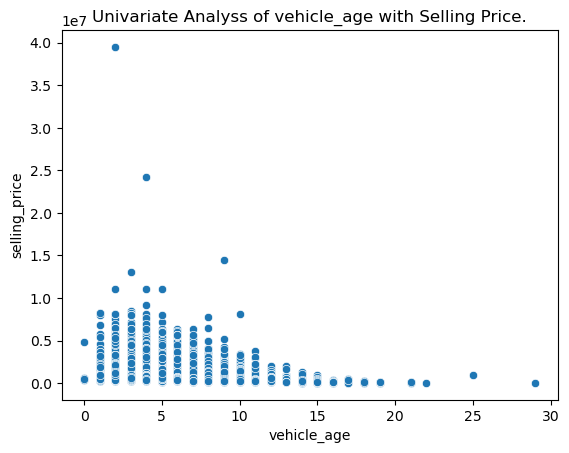

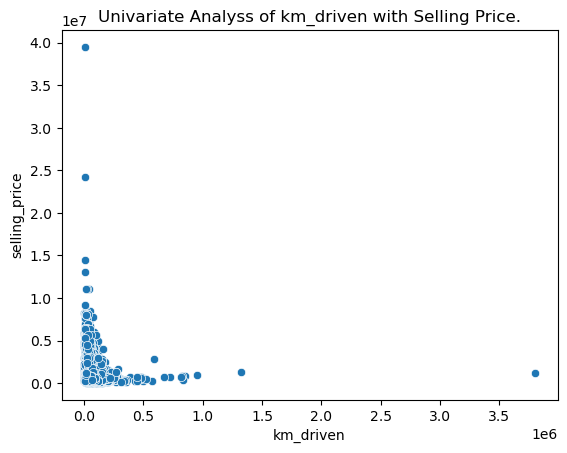

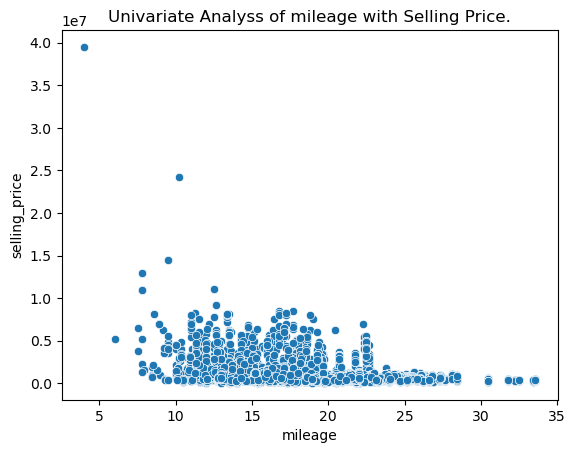

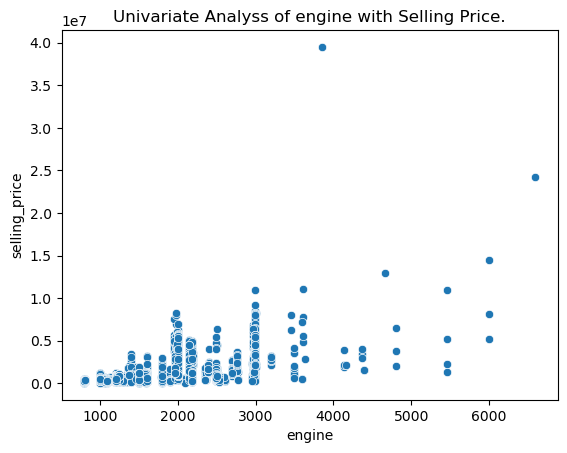

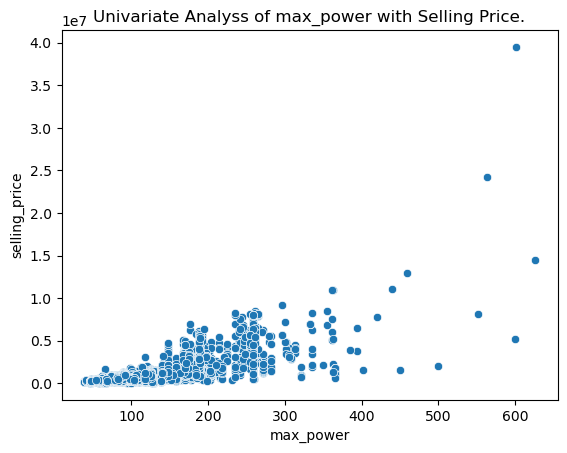

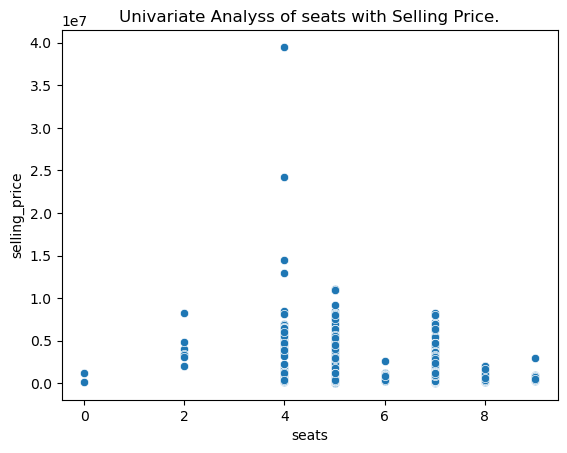

In [350]:
for cols in num_cols:
    sns.scatterplot(x= df[cols], y=df.selling_price)
    plt.title(f"Univariate Analyss of {cols} with Selling Price.")
    plt.show()

selling_price    1.000000
max_power        0.751058
engine           0.585713
seats            0.115299
km_driven       -0.079548
vehicle_age     -0.241228
mileage         -0.305128
Name: selling_price, dtype: float64


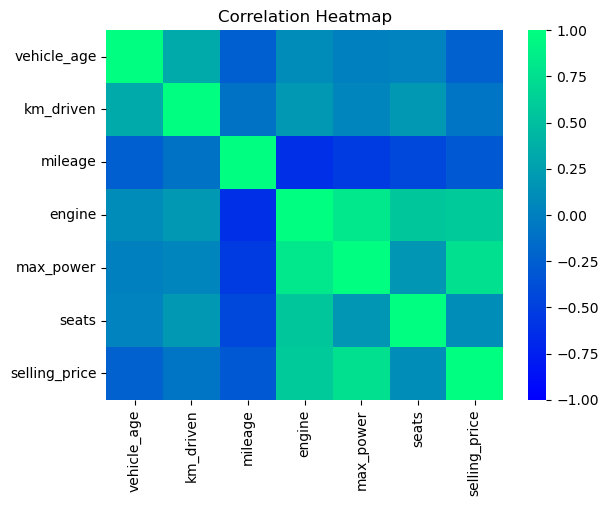

In [351]:
corr = df.select_dtypes(exclude=['object']).corr()
print(corr['selling_price'].sort_values(ascending=False))
sns.heatmap(corr, vmin=-1, vmax=1, cmap='winter')
plt.title("Correlation Heatmap")
plt.show()

`max_power` and `engine` has a strong positive correlation with `selling_price`.

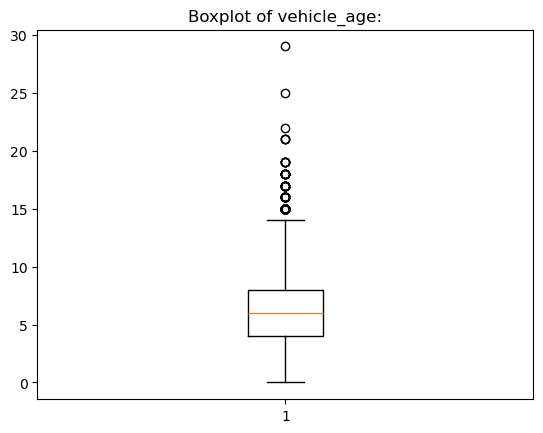

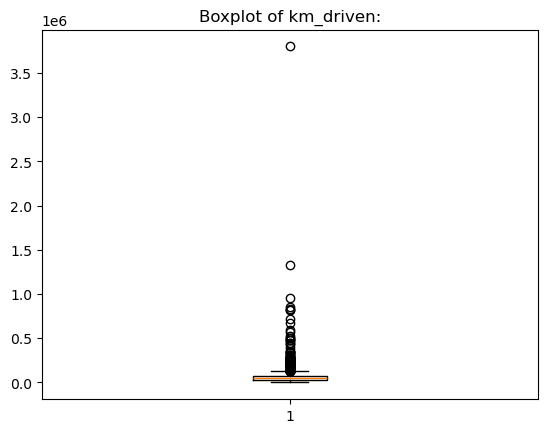

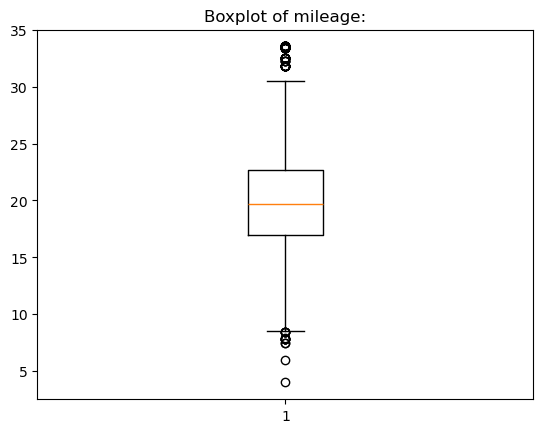

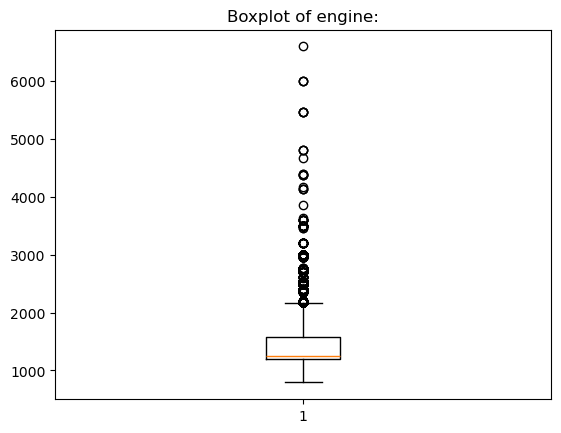

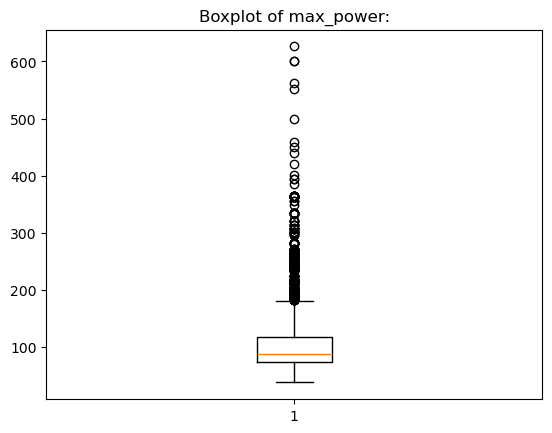

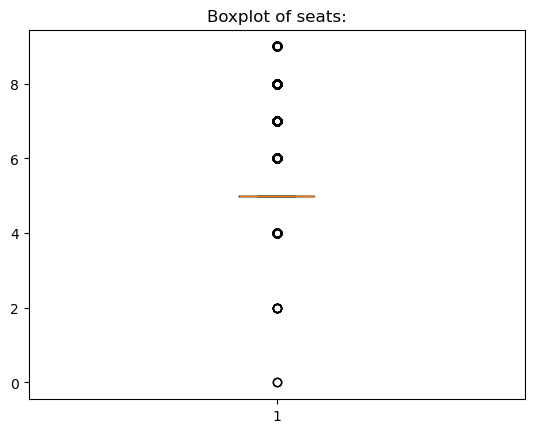

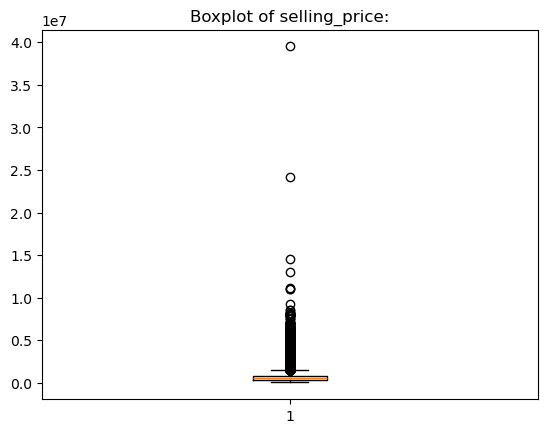

In [352]:
# Checking for Outliers.
for cols in list(df.select_dtypes(exclude=['object']).columns):
    plt.boxplot(x= df[cols])
    plt.title(f"Boxplot of {cols}:")
    plt.show()


Data has outliers but we will use Either RandomForest or XGBoost which will not be affeted by outliers so we dont have to handle it.

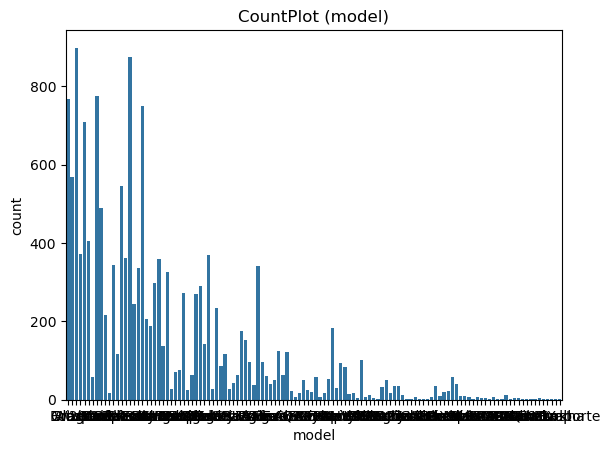

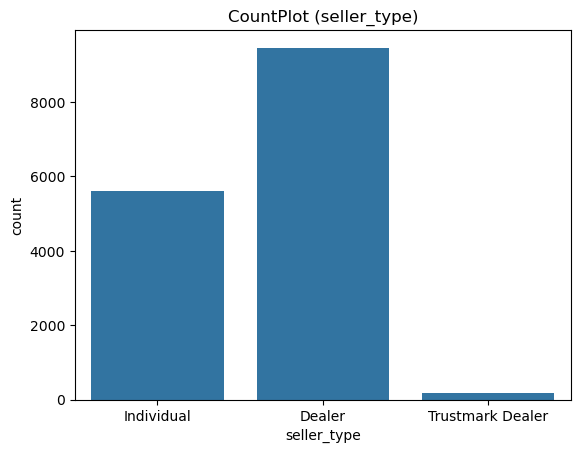

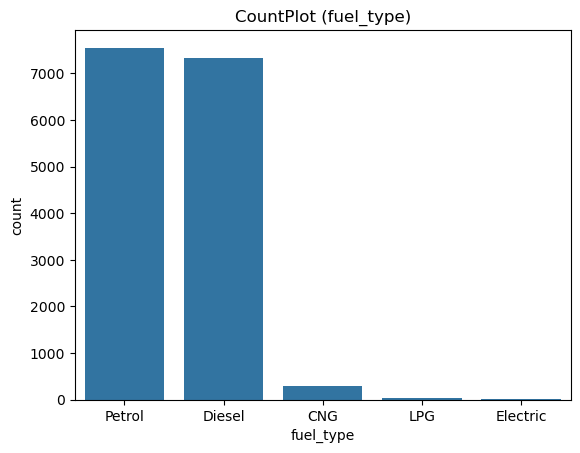

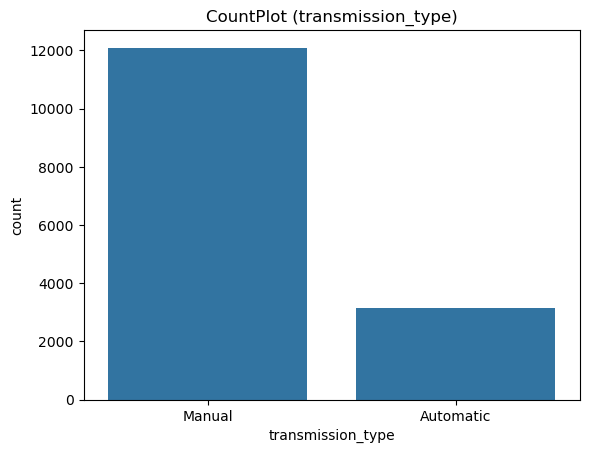

In [353]:
for cols in cat_cols:
    sns.countplot(x=df[cols])
    plt.title(f"CountPlot ({cols})")
    plt.show()

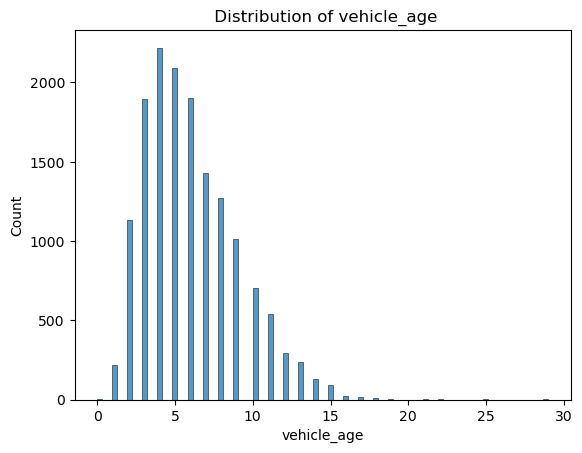

Skewness : 0.83


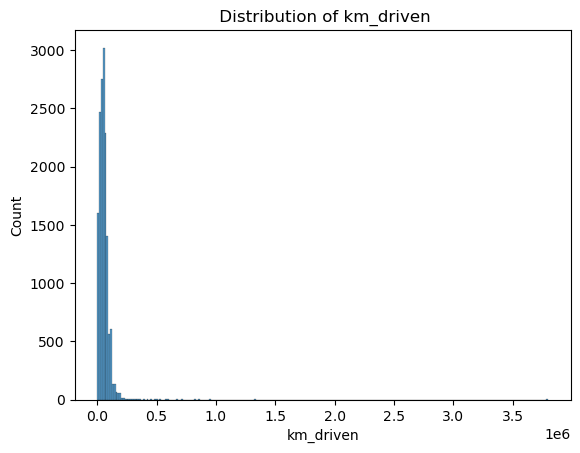

Skewness : 28.23


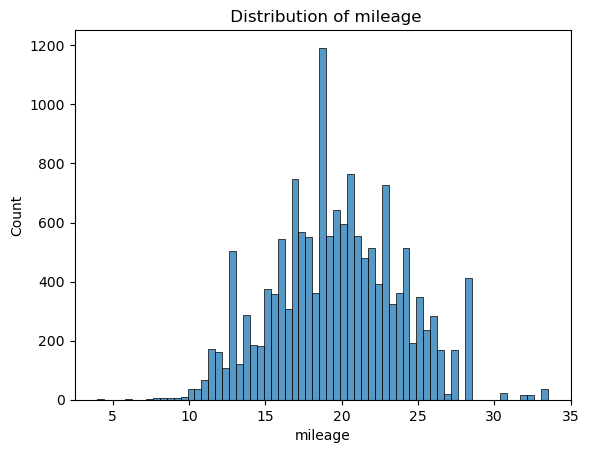

Skewness : 0.11


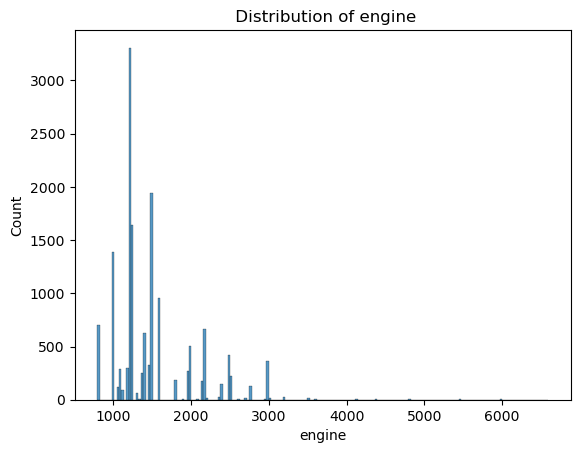

Skewness : 1.67


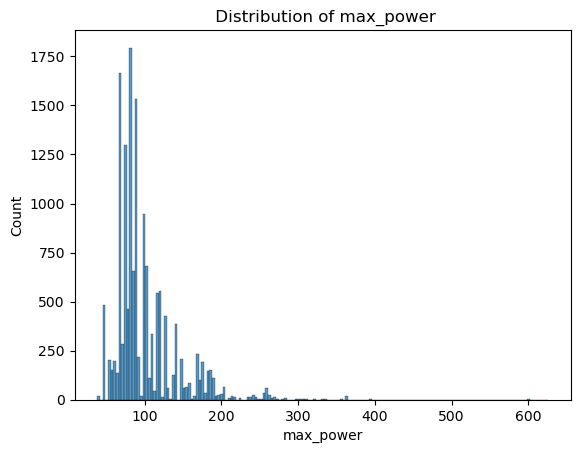

Skewness : 2.49


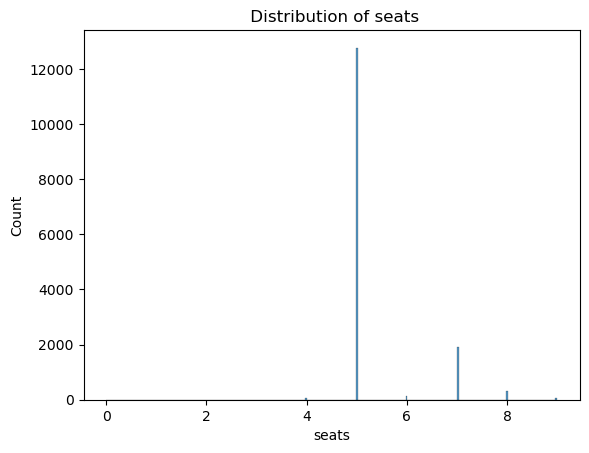

Skewness : 2.04


In [354]:
for cols in num_cols:
    sns.histplot(x = df[cols])
    plt.title(f" Distribution of {cols}")
    plt.show()
    print(f"Skewness : {(df[cols].skew()).round(2)}")

We will take log value for those columns whose skewness is greater than 1.

## 5. Data Cleaning and Preprocessing

In [355]:
log_cols = ['max_power','engine','km_driven']

In [356]:
# Checking if any columns has Zero value.
for cols in log_cols:
    print(cols, (df[cols] == 0).sum())

max_power 0
engine 0
km_driven 0


In [357]:
df = df.dropna(axis=0)
df.seats.isnull().sum(), df.shape

(np.int64(0), (15244, 11))

In [358]:
for cols in log_cols:
    df[cols] = np.log1p(df[cols])
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,11.695255,Individual,Petrol,Manual,19.70,6.680855,3.856510,5,120000
1,Grand,5,9.903538,Individual,Petrol,Manual,18.90,7.088409,4.418841,5,550000
2,i20,11,11.002117,Individual,Petrol,Manual,17.00,7.088409,4.394449,5,215000
3,Alto,9,10.518700,Individual,Petrol,Manual,20.92,6.906755,4.220977,5,226000
4,Ecosport,6,10.308986,Dealer,Diesel,Manual,22.77,7.312553,4.601062,5,570000


In [359]:
for cols in log_cols:
    print(f"{cols} = {(df[cols].skew()).round(2)}")

max_power = 0.77
engine = 0.7
km_driven = -1.04


In [360]:
le = LabelEncoder()
df['model'] = le.fit_transform(df.model)

In [361]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first')
preprocessor = ColumnTransformer([
    ('StandardScaler',scaler, num_cols),
    ('OneHotEncoder',encoder,['seller_type','fuel_type','transmission_type'])
],remainder='passthrough')

In [362]:
df = preprocessor.fit_transform(df)
df

array([[ 9.81015343e-01,  1.31404950e+00,  6.39762471e-04, ...,
         1.00000000e+00,  7.00000000e+00,  1.20000000e+05],
       [-3.45187773e-01, -9.97046920e-01, -1.91244922e-01, ...,
         1.00000000e+00,  5.40000000e+01,  5.50000000e+05],
       [ 1.64411690e+00,  4.19985319e-01, -6.46971049e-01, ...,
         1.00000000e+00,  1.18000000e+02,  2.15000000e+05],
       ...,
       [-1.36369941e-02,  5.62318545e-01,  3.46032195e-01, ...,
         1.00000000e+00,  7.70000000e+01,  4.25000000e+05],
       [-3.45187773e-01,  5.77090703e+00, -8.86826905e-01, ...,
         1.00000000e+00,  1.14000000e+02,  1.22500000e+06],
       [-1.33984011e+00, -1.55266937e+00, -4.07115193e-01, ...,
         0.00000000e+00,  2.50000000e+01,  1.20000000e+06]],
      shape=(15244, 15))

In [363]:
df = pd.DataFrame(df, columns=preprocessor.get_feature_names_out())
df.head()

,StandardScaler__vehicle_age,StandardScaler__km_driven,StandardScaler__mileage,StandardScaler__engine,StandardScaler__max_power,StandardScaler__seats,OneHotEncoder__seller_type_Individual,OneHotEncoder__seller_type_Trustmark Dealer,OneHotEncoder__fuel_type_Diesel,OneHotEncoder__fuel_type_Electric,OneHotEncoder__fuel_type_LPG,OneHotEncoder__fuel_type_Petrol,OneHotEncoder__transmission_type_Manual,remainder__model,remainder__selling_price
0,0.981015,1.314049,0.000640,-1.859596,-1.988040,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0,120000.0
1,-0.345188,-0.997047,-0.191245,-0.536586,-0.384170,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,54.0,550000.0
2,1.644117,0.419985,-0.646971,-0.536586,-0.453739,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,118.0,215000.0
3,0.981015,-0.203562,0.293264,-1.126275,-0.948513,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0,226000.0
4,-0.013637,-0.474068,0.736997,0.191037,0.135558,-0.403299,0.0,0.0,1.0,0.0,0.0,0.0,1.0,38.0,570000.0


In [364]:
X = df.drop('remainder__selling_price', axis=1)
y = df.remainder__selling_price

In [365]:
X.head()

,StandardScaler__vehicle_age,StandardScaler__km_driven,StandardScaler__mileage,StandardScaler__engine,StandardScaler__max_power,StandardScaler__seats,OneHotEncoder__seller_type_Individual,OneHotEncoder__seller_type_Trustmark Dealer,OneHotEncoder__fuel_type_Diesel,OneHotEncoder__fuel_type_Electric,OneHotEncoder__fuel_type_LPG,OneHotEncoder__fuel_type_Petrol,OneHotEncoder__transmission_type_Manual,remainder__model
0,0.981015,1.314049,0.000640,-1.859596,-1.988040,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0
1,-0.345188,-0.997047,-0.191245,-0.536586,-0.384170,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,54.0
2,1.644117,0.419985,-0.646971,-0.536586,-0.453739,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,118.0
3,0.981015,-0.203562,0.293264,-1.126275,-0.948513,-0.403299,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0
4,-0.013637,-0.474068,0.736997,0.191037,0.135558,-0.403299,0.0,0.0,1.0,0.0,0.0,0.0,1.0,38.0


In [366]:
y

0         120000.0
1         550000.0
2         215000.0
3         226000.0
4         570000.0
           ...    
15239     250000.0
15240     925000.0
15241     425000.0
15242    1225000.0
15243    1200000.0
Name: remainder__selling_price, Length: 15244, dtype: float64

In [367]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=0.25, random_state=42)
xtrain.shape, ytest.shape

((11433, 14), (3811,))

## 6. Training Models

In [368]:
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet':ElasticNet(),
    'RandomForestRegressor':RandomForestRegressor(),
    'Lasso':Lasso(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'XGBRegressor': XGBRegressor()
}

In [369]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    mae_test = mean_absolute_error(y_test,y_pred_test)
    mae_train = mean_absolute_error(y_train,y_pred_train)
    rmse_test = root_mean_squared_error(y_test,y_pred_test)
    rmse_train = root_mean_squared_error(y_train,y_pred_train)
    r2score_test = r2_score(y_test,y_pred_test)
    r2score_train = r2_score(y_train,y_pred_train)
    return mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train

In [370]:
res = []
for name,m in models.items():
    model = m
    model.fit(xtrain,ytrain)
    y_pred_test = model.predict(xtest)
    y_pred_train = model.predict(xtrain)
    mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train = check_score(y_pred_test,ytest,y_pred_train,ytrain)
    res.append({
            'Model':name,
            'MAE Test':mae_test,
            'MAE Train':mae_train,
            'RMSE Test':rmse_test,
            'RMSE Train':rmse_train,
            'R2 Score Test':r2score_test,
            'R2 Score Train':r2score_train
        })
    print(f"{name} Model Trained Sucessfully.")


LinearRegression Model Trained Sucessfully.
ElasticNet Model Trained Sucessfully.
RandomForestRegressor Model Trained Sucessfully.
Lasso Model Trained Sucessfully.
DecisionTreeRegressor Model Trained Sucessfully.
XGBRegressor Model Trained Sucessfully.


## 7. Comparing the Models based on Performance Metrices

In [ ]:
res_df = pd.DataFrame(res).sort_values(by='R2 Score Test', ascending=False)
res_df

<Axes: xlabel='Model'>

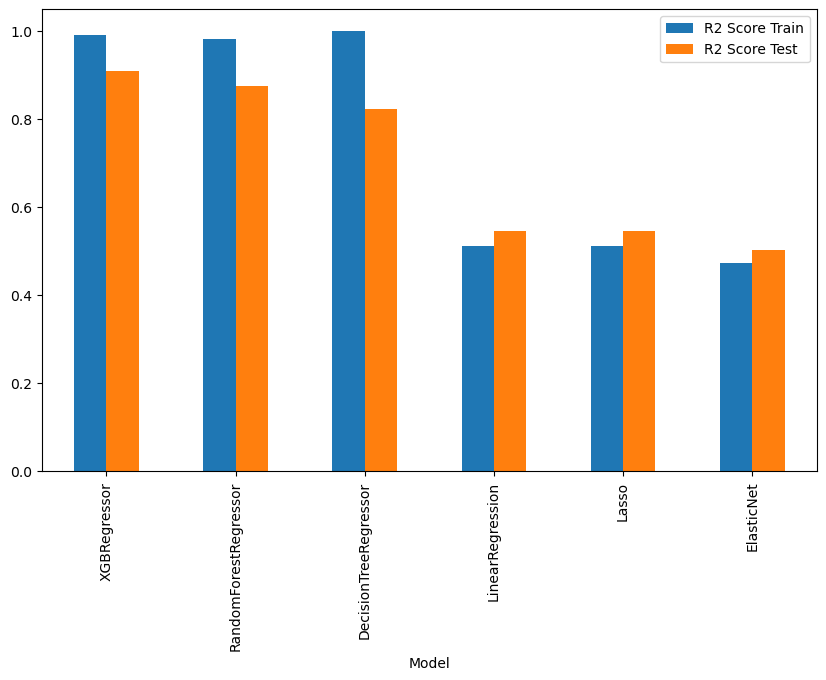

In [372]:
res_df.set_index(['Model'])[['R2 Score Train','R2 Score Test']].plot(kind='bar',figsize=(10,6))

## 8. Hyper-parameter Tuning

In [373]:
mod = XGBRegressor()
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [3, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
gs = GridSearchCV( mod, param_grid=parameters)
gs.fit(xtrain,ytrain)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 7], 'n_estimators': [100, 200], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [374]:
gs.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 7,
 'n_estimators': 200,
 'subsample': 1.0}

In [377]:
xgb = XGBRegressor(learning_rate = 0.1, max_depth = 7, n_estimators = 200, subsample = 1.0)
xgb.fit(xtrain,ytrain)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [ ]:
ytestpred = xgb.predict(xtest)
ytrainpred = xgb.predict(xtrain)

In [ ]:
print(f"Test Score after Tuning : {r2_score(ytest, ytestpred)}")
print(f"Train Score after Tuning : {r2_score(ytrain, ytrainpred)}")

Test Score after Tuning : 0.9135643378227898
Train Score after Tuning : 0.9908919061149544


## 9. Testing on Unseen Data

In [380]:
unseen_data = X.sample(5, random_state=30)
unseen_pred = xgb.predict(unseen_data)
pd.DataFrame(unseen_pred,columns=[['Pridected Price']])

,Pridected Price
0,397548.062500
1,645353.187500
2,879154.812500
3,222009.453125
4,196604.125000


## 10. Conclusion

- Trained and compared 5 models (LinearRegression,ElasticNet,RandomForestRegressor,Lasso,DecisionTreeRegressor) with hyperparameter tuning.
- The best-performing model was selected based on R2 Score.
- The selected model was used to predict on unseen samples successfully.